# Impact data

Subnational impact data from HDX

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [109]:
from io import BytesIO

import pandas as pd
import matplotlib.pyplot as plt

from src.utils import blob_utils
from src.datasources import codab
from src.constants import *

In [16]:
adm2 = codab.load_codab_from_blob(admin_level=2)

<Axes: >

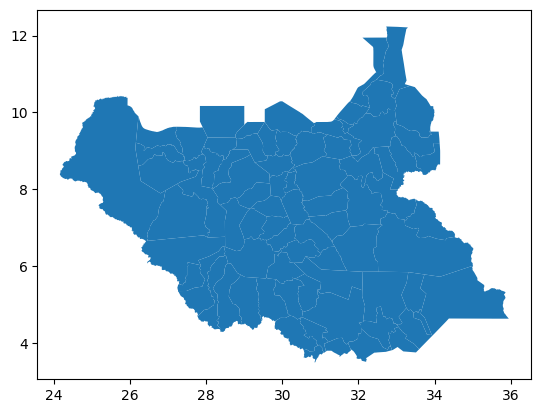

In [17]:
adm2.plot()

In [48]:
df_all = pd.DataFrame(columns=["year", "ADM2_PCODE", "total_affected"])

In [93]:
year = 2024
blob_name = f"{PROJECT_PREFIX}/raw/impact/ssd_flood_response_20122024.xlsx"

df_in = pd.read_excel(BytesIO(blob_utils._load_blob_data(blob_name)))

df_in = df_in.rename(
    columns={"Admin2_Pcode": "ADM2_PCODE", "People_Affected": "total_affected"}
)

df_in = df_in.dropna(subset="ADM2_PCODE")

assert all([x in adm2["ADM2_PCODE"].to_list() for x in df_in["ADM2_PCODE"]])

df_in["year"] = year

cols = ["ADM2_PCODE", "year", "total_affected"]
df_all = df_all.merge(df_in[cols], how="outer")

<Axes: >

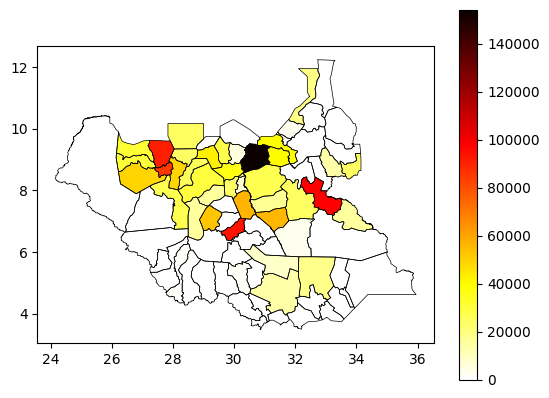

In [120]:
fig, ax = plt.subplots()
adm2.merge(df_all).plot(
    column="total_affected", ax=ax, cmap="hot_r", legend=True
)
adm2.boundary.plot(ax=ax, color="k", linewidth=0.5)

In [97]:
year = 2022
blob_name = (
    f"{PROJECT_PREFIX}/raw/impact/ss_floodsaffected_people_20211213.xlsx"
)

In [98]:
df_in = pd.read_excel(BytesIO(blob_utils._load_blob_data(blob_name)))

In [100]:
cols = ["State", "County", "Affected People"]
df_in = df_in[cols]

In [102]:
df_in = df_in.dropna()

In [ ]:
isinstance()

In [105]:
df_in = df_in[df_in["Affected People"]]

TypeError: '>' not supported between instances of 'str' and 'int'

In [91]:
df_all["total_affected"] = df_all["total_affected"].astype(int)

In [92]:
df_all

,year,ADM2_PCODE,total_affected
0,2024,SS0001,24468
1,2024,SS0101,13320
2,2024,SS0105,8503
3,2024,SS0206,18178
4,2024,SS0301,97730
5,2024,SS0302,26700
6,2024,SS0303,2946
7,2024,SS0304,39971
8,2024,SS0305,16771
9,2024,SS0306,154005
